In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from ANN import Model, Layer, ReLu, ReLu_derive, softmax

In [28]:
df = pd.read_csv("./digit-recognizer/train.csv")
X = df.drop(columns='label')
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)
X_train = np.array(X_train) / 255.0
X_test = np.array(X_test) / 255.0
X_train.shape

(33600, 784)

In [35]:
model = Model(
  500,
  0.2
)
l1 = Layer(128, 784, ReLu, ReLu_derive)
l2 = Layer(64, 128, ReLu, ReLu_derive)
l3 = Layer(10, 64, softmax)
model.add_layer(l1)
model.add_layer(l2)
model.add_layer(l3)
model.fit(X_train, y_train)

Iteration 0 | Loss: 14.7872 | Accuracy: 0.1408
Iteration 10 | Loss: 1.8046 | Accuracy: 0.4178
Iteration 20 | Loss: 1.2763 | Accuracy: 0.5992
Iteration 30 | Loss: 0.9877 | Accuracy: 0.6848
Iteration 40 | Loss: 0.8360 | Accuracy: 0.7327
Iteration 50 | Loss: 0.7397 | Accuracy: 0.7632
Iteration 60 | Loss: 0.6698 | Accuracy: 0.7852
Iteration 70 | Loss: 0.6163 | Accuracy: 0.8034
Iteration 80 | Loss: 0.5741 | Accuracy: 0.8172
Iteration 90 | Loss: 0.5398 | Accuracy: 0.8285
Iteration 100 | Loss: 0.5111 | Accuracy: 0.8381
Iteration 110 | Loss: 0.4867 | Accuracy: 0.8468
Iteration 120 | Loss: 0.4655 | Accuracy: 0.8540
Iteration 130 | Loss: 0.4469 | Accuracy: 0.8604
Iteration 140 | Loss: 0.4304 | Accuracy: 0.8657
Iteration 150 | Loss: 0.4156 | Accuracy: 0.8702
Iteration 160 | Loss: 0.4023 | Accuracy: 0.8751
Iteration 170 | Loss: 0.3901 | Accuracy: 0.8794
Iteration 180 | Loss: 0.3789 | Accuracy: 0.8829
Iteration 190 | Loss: 0.3686 | Accuracy: 0.8860
Iteration 200 | Loss: 0.3592 | Accuracy: 0.8885
It

In [36]:
train_acc = model.accuracy(X_train, y_train)
print(f"Train Accuracy: {train_acc:.4f}")

test_acc = model.accuracy(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9305
Test Accuracy: 0.9123


# Testing the model

In [37]:
def show_digit(X, y=None, index=0):
	image = X[index].reshape(28, 28)

	plt.figure(figsize=(4, 4))
	plt.imshow(image, cmap="gray")
	plt.axis("off")

	if y is not None:
		plt.title(f"Label: {y[index]}")

	plt.show()

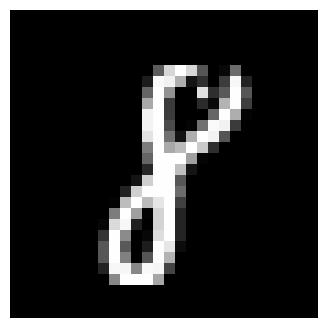

np.int64(8)

In [38]:
test_df = pd.read_csv("./digit-recognizer/test.csv")
X = np.array(test_df)/255.0
show_digit(X, index=52)
pred = model.predict(X)
pred[52]